# Dự đoán khách hàng có sử dụng thẻ tín dụng (Fintech VIB)

**Mục tiêu:** dùng thông tin khách hàng, giao dịch MyVIB, hoạt động MyVIB, tiền gửi và cho vay để dự đoán khách hàng có thẻ tín dụng hay không.

**Nhãn (target):** với mỗi khách hàng trong file 6 (Card), lấy **giá trị lớn nhất** của `COUNT_CREDITCARD` qua 12 tháng. Bằng 0 thì nhãn là **0** (không mở thẻ), lớn hơn 0 thì nhãn là **1** (có thẻ).

## 1. Các file và ý nghĩa thuộc tính

| File | Một dòng là | Thuộc tính chính |
|---|---|---|
| 1. Customer | 1 khách hàng | `CLIENT_SEX` giới tính, `DATE_OF_BIRTH` ngày sinh, `CLIENT_CREATE_DATE` ngày tạo khách hàng, `STAFF_VIB` nhân viên VIB, `IB_REGISTER_DATE` ngày đăng ký Internet Banking, `EB_REGISTER_CHANNEL` kênh đăng ký, `SMS` có dùng SMS, `VERIFY_METHOD` cách xác thực |
| 2. MyVIB Transaction | giao dịch gộp theo ngày, giờ, loại | `TRANS_LV1`, `TRANS_LV2` nhóm giao dịch (Transfer, Payment, Topup...), `TRANS_DATE`, `DAY_OF_WEEK`, `TRANS_HOUR`, `TRANS_NO` số giao dịch, `TRANS_AMOUNT` số tiền |
| 3. MyVIB Activity | hoạt động trên app | `ACTIVITY_DATE`, `ACTIVITY_HOUR`, `ACTIVITY_NO`, `ACTIVITY_NAME` loại hoạt động (LOGIN, xem lãi suất, ...) |
| 4. Deposit | khách hàng theo tháng | `COUNT_CA_ACCT`, `AVG_CA_BALANCE` tài khoản thanh toán; `COUNT_TD_ACCT`, `AVG_TD_BALANCE` tiền gửi có kỳ hạn |
| 5. Lending | khách hàng theo tháng | `COUNT_OF_LOAN` số khoản vay, `AVG_LOAN_AMOUNT` số tiền vay bình quân |
| 6. Card | khách hàng theo tháng | `COUNT_CREDITCARD` số thẻ tín dụng (dùng để tạo nhãn) |

Khoá nối giữa các file là `CUSTOMER_NUMBER`. Lưu ý: ở file xlsx (5, 6) mã khách hàng bị mất số 0 ở đầu (ví dụ `914326`), còn ở file csv có đủ 8 chữ số (`00914326`), nên cần chuẩn hoá bằng `zfill(8)` trước khi nối.

## 2. Nạp dữ liệu

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Học máy/Fintect/'
FILES = dict(customer='1.Data_Customer.csv',
             trans='2.Data_MyVIB_Transaction.csv',
             activity='3.Data_MyVIB_Activity.csv',
             deposit='4.Data_Deposit.csv',
             lending='5.Data_Lending.xlsx',
             card='6.Data_Card.xlsx')
PATH = {k: BASE + v for k, v in FILES.items()}

for k, p in PATH.items():
    print(f'{k:10s}', os.path.exists(p), p)

Mounted at /content/drive
customer   True /content/drive/MyDrive/Học máy/Fintect/1.Data_Customer.csv
trans      True /content/drive/MyDrive/Học máy/Fintect/2.Data_MyVIB_Transaction.csv
activity   True /content/drive/MyDrive/Học máy/Fintect/3.Data_MyVIB_Activity.csv
deposit    True /content/drive/MyDrive/Học máy/Fintect/4.Data_Deposit.csv
lending    True /content/drive/MyDrive/Học máy/Fintect/5.Data_Lending.xlsx
card       True /content/drive/MyDrive/Học máy/Fintect/6.Data_Card.xlsx


In [2]:
def fix_id(s):
    # Chuẩn hoá mã khách hàng về 8 chữ số
    return s.astype(str).str.strip().str.replace(r'\.0$', '', regex=True).str.zfill(8)

cust = pd.read_csv(PATH['customer'], dtype=str)
tr   = pd.read_csv(PATH['trans'], dtype={'CUSTOMER_NUMBER': str})
dep  = pd.read_csv(PATH['deposit'], dtype={'CUSTOMER_NUMBER': str})
lend = pd.read_excel(PATH['lending'], dtype={'CUSTOMER_NUMBER': str})
card = pd.read_excel(PATH['card'], dtype={'CUSTOMER_NUMBER': str})

for d in (cust, tr, dep, lend, card):
    d['CUSTOMER_NUMBER'] = fix_id(d['CUSTOMER_NUMBER'])

# File Activity rất lớn (~16 triệu dòng): đọc theo từng khối và đếm số lần mỗi loại hoạt động
parts, n_act_rows = [], 0
for ch in pd.read_csv(PATH['activity'], usecols=['CUSTOMER_NUMBER', 'ACTIVITY_NAME'],
                      dtype=str, chunksize=2_000_000, on_bad_lines='skip'):
    n_act_rows += len(ch)
    parts.append(ch.groupby(['CUSTOMER_NUMBER', 'ACTIVITY_NAME']).size())
act = pd.concat(parts).groupby(level=[0, 1]).sum().unstack(fill_value=0)
act.index = fix_id(act.index.to_series()).values
print('Activity: số dòng', n_act_rows, '| số khách hàng', len(act), '| số loại hoạt động', act.shape[1])

Activity: số dòng 16132675 | số khách hàng 77741 | số loại hoạt động 45


In [3]:
overview = pd.DataFrame({
    'Số dòng':           [len(cust), len(tr), n_act_rows, len(dep), len(lend), len(card)],
    'Số khách hàng':     [cust.CUSTOMER_NUMBER.nunique(), tr.CUSTOMER_NUMBER.nunique(), len(act),
                          dep.CUSTOMER_NUMBER.nunique(), lend.CUSTOMER_NUMBER.nunique(), card.CUSTOMER_NUMBER.nunique()],
    'Số cột':            [cust.shape[1], tr.shape[1], 6, dep.shape[1], lend.shape[1], card.shape[1]],
}, index=['1 Customer', '2 Transaction', '3 Activity', '4 Deposit', '5 Lending', '6 Card'])
overview

,Số dòng,Số khách hàng,Số cột
1 Customer,290223,290223,9
2 Transaction,1418030,52488,8
3 Activity,16132675,77741,6
4 Deposit,1258424,223817,6
5 Lending,576431,102014,4
6 Card,871589,150459,3


In [4]:
# Giá trị thiếu và các giá trị phân loại của file Customer
print(cust.isna().mean().round(3).rename('Tỉ lệ thiếu').to_frame().T.to_string())
for col in ['CLIENT_SEX', 'STAFF_VIB', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD']:
    print(f'\n{col}:', cust[col].value_counts(dropna=False).to_dict())

print('\nCác loại giao dịch (TRANS_LV1 / TRANS_LV2):')
print(tr.groupby(['TRANS_LV1', 'TRANS_LV2']).agg(so_dong=('TRANS_NO', 'size'),
                                                  tong_tien=('TRANS_AMOUNT', 'sum')).to_string())
print('\nCác loại hoạt động:', list(act.columns))

             CUSTOMER_NUMBER  CLIENT_SEX  CLIENT_CREATE_DATE  DATE_OF_BIRTH  STAFF_VIB  IB_REGISTER_DATE  EB_REGISTER_CHANNEL    SMS  VERIFY_METHOD
Tỉ lệ thiếu              0.0       0.015                 0.0          0.015        0.0             0.452                0.452  0.452          0.452

CLIENT_SEX: {'M': 155636, 'F': 130304, nan: 4283}

STAFF_VIB: {'N': 288354, 'Y': 1869}

EB_REGISTER_CHANNEL: {nan: 131248, 'BRANCH': 117161, 'AUTO-JOB': 29456, 'MYVIB': 12254, 'WEBSITE': 104}

SMS: {nan: 131248, 'Y': 87416, 'N': 71559}

VERIFY_METHOD: {nan: 131276, 'SMART_OTP': 130722, 'SMS': 28127, 'HARD_TOKEN': 98}

Các loại giao dịch (TRANS_LV1 / TRANS_LV2):
                                 so_dong     tong_tien
TRANS_LV1 TRANS_LV2                                   
Payment   Credit_card_repayment    51185  1.414126e+12
          Insurance_payment          742  1.661803e+10
          Lending_repayment          287  7.013073e+08
          Lifestyle_payment          451  5.594407e+08
         

## 3. Tạo nhãn: khách hàng có thẻ tín dụng hay không

In [5]:
y = card.groupby('CUSTOMER_NUMBER')['COUNT_CREDITCARD'].max().gt(0).astype(int).rename('HAS_CARD')
base = y.to_frame()

print('Số khách hàng có nhãn:', len(base))
print(base['HAS_CARD'].value_counts().rename({0: '0 - không có thẻ', 1: '1 - có thẻ'}).to_frame('Số khách'))
print('Tỉ lệ có thẻ:', round(base['HAS_CARD'].mean() * 100, 1), '%')

Số khách hàng có nhãn: 150459
                  Số khách
HAS_CARD                  
0 - không có thẻ    108085
1 - có thẻ           42374
Tỉ lệ có thẻ: 28.2 %


## 4. Kiểm tra rò rỉ dữ liệu (data leakage)

Trong file giao dịch có loại **`Credit_card_repayment`** (trả nợ thẻ tín dụng). Khách đã trả nợ thẻ thì hiển nhiên có thẻ, nên đưa đặc trưng này vào mô hình sẽ làm kết quả đẹp một cách giả tạo. Ở file Activity cũng có hoạt động `CARD_EGIFT_REGISTER_CASHBACK` (đăng ký hoàn tiền thẻ) cùng bản chất. Hai loại này sẽ bị **loại khỏi đặc trưng**.

In [6]:
repay_ids = set(tr.loc[tr.TRANS_LV2 == 'Credit_card_repayment', 'CUSTOMER_NUMBER'])
chk = base.copy()
chk['Có giao dịch trả nợ thẻ'] = chk.index.isin(repay_ids)
print(pd.crosstab(chk['Có giao dịch trả nợ thẻ'], chk['HAS_CARD'], normalize='index').round(3) * 100)
print('\nSố khách theo nhóm:')
print(chk['Có giao dịch trả nợ thẻ'].value_counts())

HAS_CARD                    0     1
Có giao dịch trả nợ thẻ            
False                    74.9  25.1
True                      5.8  94.2

Số khách theo nhóm:
Có giao dịch trả nợ thẻ
False    143743
True       6716
Name: count, dtype: int64


## 5. Trích đặc trưng từ từng file rồi gộp theo khách hàng

In [7]:
REF = pd.Timestamp('2019-12-31')

# ---- File 1: Customer ----
c = cust.set_index('CUSTOMER_NUMBER')
age = (REF - pd.to_datetime(c['DATE_OF_BIRTH'], errors='coerce')).dt.days / 365.25
f_cust = pd.DataFrame({
    'age': age.where(age.between(16, 90)),                       # tuổi ngoài 16-90 coi là lỗi nhập liệu
    'tenure_days': (REF - pd.to_datetime(c['CLIENT_CREATE_DATE'], errors='coerce')).dt.days,
    'staff_vib': (c['STAFF_VIB'] == 'Y').astype(int),
    'has_ib': c['IB_REGISTER_DATE'].notna().astype(int),
    'sex': c['CLIENT_SEX'].fillna('UNK'),
    'channel': c['EB_REGISTER_CHANNEL'].fillna('NONE'),
    'sms': c['SMS'].fillna('NONE'),
    'verify': c['VERIFY_METHOD'].fillna('NONE'),
})
f_cust = pd.get_dummies(f_cust, columns=['sex', 'channel', 'sms', 'verify'], dtype=int)

# ---- File 2: Transaction (đã bỏ Credit_card_repayment) ----
t = tr[tr.TRANS_LV2 != 'Credit_card_repayment'].copy()
t['month'] = t['TRANS_DATE'].str[:7]
t['weekend'] = t['DAY_OF_WEEK'].isin(['Sat', 'Sun']).astype(int)
g = t.groupby('CUSTOMER_NUMBER')
f_tr = pd.DataFrame({
    'tx_rows': g.size(),
    'tx_count': g['TRANS_NO'].sum(),
    'tx_amount_sum': g['TRANS_AMOUNT'].sum(),
    'tx_amount_mean': g['TRANS_AMOUNT'].mean(),
    'tx_amount_max': g['TRANS_AMOUNT'].max(),
    'tx_active_days': g['TRANS_DATE'].nunique(),
    'tx_active_months': g['month'].nunique(),
    'tx_hour_mean': g['TRANS_HOUR'].mean(),
    'tx_weekend_ratio': g['weekend'].mean(),
})
tx_n = t.pivot_table(index='CUSTOMER_NUMBER', columns='TRANS_LV2', values='TRANS_NO', aggfunc='sum', fill_value=0).add_prefix('txn_')
tx_a = t.pivot_table(index='CUSTOMER_NUMBER', columns='TRANS_LV2', values='TRANS_AMOUNT', aggfunc='sum', fill_value=0).add_prefix('txa_')
f_tr = f_tr.join(tx_n).join(tx_a)

# ---- File 3: Activity (bỏ các hoạt động liên quan thẻ) ----
a = act.drop(columns=[x for x in act.columns if x.startswith('CARD_') or x == 'CA'], errors='ignore').add_prefix('act_')
a['act_total'] = a.sum(axis=1)
login_cols = [x for x in a.columns if x.startswith('act_LOGIN') and x != 'act_LOGOUT']
a['act_biometric_ratio'] = (a.get('act_LOGIN_FINGER', 0) + a.get('act_LOGIN_FACEID', 0)) / a[login_cols].sum(axis=1).replace(0, np.nan)
f_act = a

# ---- File 4: Deposit ----
g = dep.groupby('CUSTOMER_NUMBER')
f_dep = pd.DataFrame({
    'dep_months': g['MONTH'].nunique(),
    'ca_acct_max': g['COUNT_CA_ACCT'].max(),
    'ca_bal_mean': g['AVG_CA_BALANCE'].mean(),
    'ca_bal_max': g['AVG_CA_BALANCE'].max(),
    'td_acct_max': g['COUNT_TD_ACCT'].max(),
    'td_bal_mean': g['AVG_TD_BALANCE'].mean(),
    'td_bal_max': g['AVG_TD_BALANCE'].max(),
})

# ---- File 5: Lending ----
g = lend.groupby('CUSTOMER_NUMBER')
f_lend = pd.DataFrame({
    'loan_months': g['MONTH'].nunique(),
    'loan_count_max': g['COUNT_OF_LOAN'].max(),
    'loan_amt_mean': g['AVG_LOAN_AMOUNT'].mean(),
    'loan_amt_max': g['AVG_LOAN_AMOUNT'].max(),
})

# ---- Gộp vào bảng nhãn (left join theo khách hàng có nhãn) ----
feats = base.join(f_cust).join(f_tr).join(f_act).join(f_dep).join(f_lend)

# Cờ cho biết khách có xuất hiện trong từng file hay không
feats['has_myvib_tx'] = feats.index.isin(f_tr.index).astype(int)
feats['has_myvib_act'] = feats.index.isin(f_act.index).astype(int)
feats['has_deposit'] = feats.index.isin(f_dep.index).astype(int)
feats['has_loan'] = feats.index.isin(f_lend.index).astype(int)

# Khách không có dòng nào trong file giao dịch, hoạt động, tiền gửi, cho vay: coi là chưa phát sinh (điền 0)
zero_cols = [x for x in feats.columns if x.startswith(('tx_', 'txn_', 'txa_', 'act_', 'dep_', 'ca_', 'td_', 'loan_'))
             and x not in ('tx_hour_mean', 'tx_weekend_ratio', 'act_biometric_ratio')]
feats[zero_cols] = feats[zero_cols].fillna(0)

print('Bảng sau khi gộp:', feats.shape)
feats.to_csv(BASE + 'merged_features.csv')   # lưu lại để dùng lần sau

Bảng sau khi gộp: (150459, 114)


## 6. Mô tả bảng dữ liệu sau khi gộp

In [8]:
print('Số khách hàng:', len(feats), '| Số đặc trưng:', feats.shape[1] - 1)
print('\nĐộ phủ: % khách có nhãn xuất hiện trong từng nguồn')
print((feats[['has_myvib_tx', 'has_myvib_act', 'has_deposit', 'has_loan']].mean() * 100).round(1).to_string())

miss = feats.isna().mean()
print('\nCột còn thiếu giá trị (sẽ được xử lý khi huấn luyện):')
print((miss[miss > 0] * 100).round(1).sort_values(ascending=False).head(10).to_string())

feats.drop(columns='HAS_CARD').describe().T.round(2).head(25)

Số khách hàng: 150459 | Số đặc trưng: 113

Độ phủ: % khách có nhãn xuất hiện trong từng nguồn
has_myvib_tx     29.2
has_myvib_act    41.6
has_deposit      76.8
has_loan         28.7

Cột còn thiếu giá trị (sẽ được xử lý khi huấn luyện):
tx_hour_mean           70.8
tx_weekend_ratio       70.8
act_biometric_ratio    59.0
age                     0.3


,count,mean,std,min,25%,50%,75%,max
age,150004.0,30.96,9.430000e+00,16.0,24.04,28.77,35.81,8.971000e+01
tenure_days,150459.0,170.66,9.985000e+01,0.0,84.00,165.00,255.00,3.640000e+02
staff_vib,150459.0,0.01,1.100000e-01,0.0,0.00,0.00,0.00,1.000000e+00
has_ib,150459.0,0.75,4.400000e-01,0.0,0.00,1.00,1.00,1.000000e+00
sex_F,150459.0,0.43,5.000000e-01,0.0,0.00,0.00,1.00,1.000000e+00
sex_M,150459.0,0.57,5.000000e-01,0.0,0.00,1.00,1.00,1.000000e+00
sex_UNK,150459.0,0.00,2.000000e-02,0.0,0.00,0.00,0.00,1.000000e+00
channel_AUTO-JOB,150459.0,0.15,3.600000e-01,0.0,0.00,0.00,0.00,1.000000e+00
channel_BRANCH,150459.0,0.52,5.000000e-01,0.0,0.00,1.00,1.00,1.000000e+00
channel_MYVIB,150459.0,0.07,2.600000e-01,0.0,0.00,0.00,0.00,1.000000e+00


## 7. Trực quan hoá dữ liệu

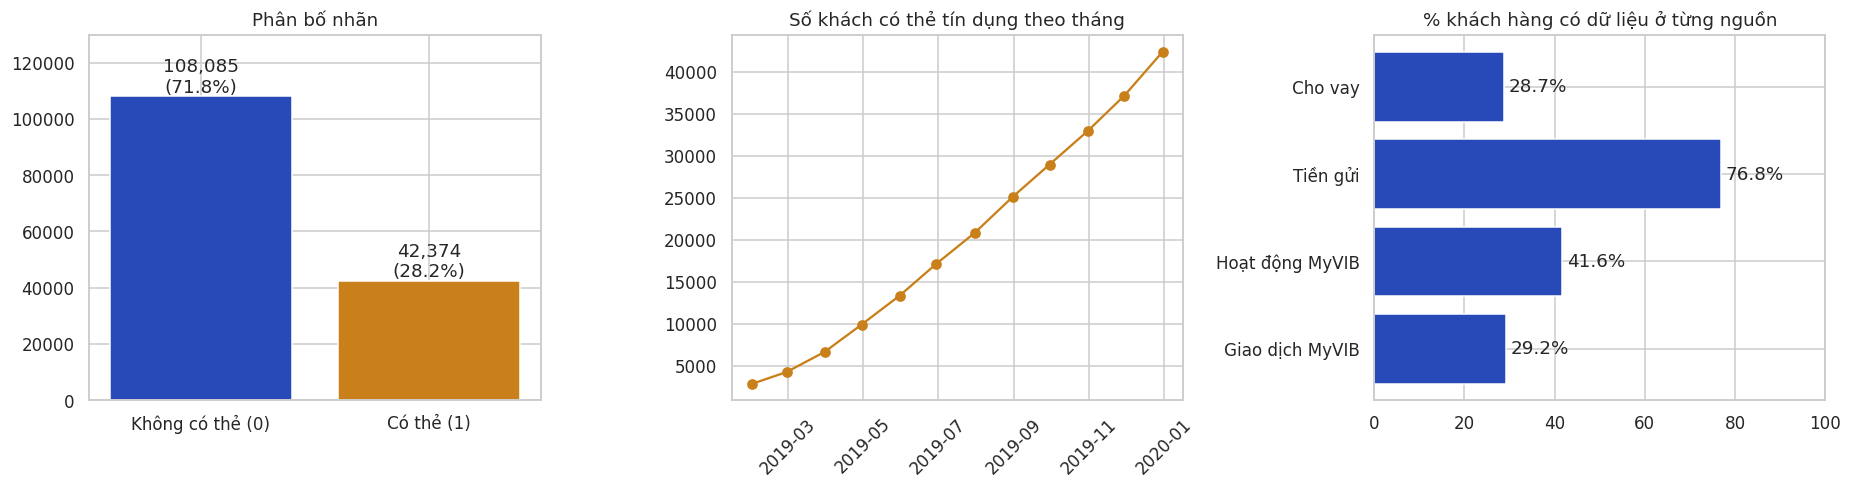

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
colors = ['#2849b8', '#c9801a']

# (a) Phân bố nhãn
vc = feats['HAS_CARD'].value_counts().sort_index()
axes[0].bar(['Không có thẻ (0)', 'Có thẻ (1)'], vc.values, color=colors)
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(feats):.1%})', ha='center', va='bottom')
axes[0].set_ylim(0, vc.max() * 1.2)
axes[0].set_title('Phân bố nhãn')

# (b) Số khách có thẻ theo tháng
m = card.assign(has=card.COUNT_CREDITCARD > 0).groupby('MONTH')['has'].sum()
axes[1].plot(m.index, m.values, marker='o', color='#c9801a')
axes[1].set_title('Số khách có thẻ tín dụng theo tháng')
axes[1].tick_params(axis='x', rotation=45)

# (c) Độ phủ của các nguồn dữ liệu
cov = feats[['has_myvib_tx', 'has_myvib_act', 'has_deposit', 'has_loan']].mean() * 100
axes[2].barh(['Giao dịch MyVIB', 'Hoạt động MyVIB', 'Tiền gửi', 'Cho vay'], cov.values, color='#2849b8')
for i, v in enumerate(cov.values):
    axes[2].text(v + 1, i, f'{v:.1f}%', va='center')
axes[2].set_xlim(0, 100)
axes[2].set_title('% khách hàng có dữ liệu ở từng nguồn')
plt.tight_layout(); plt.show()

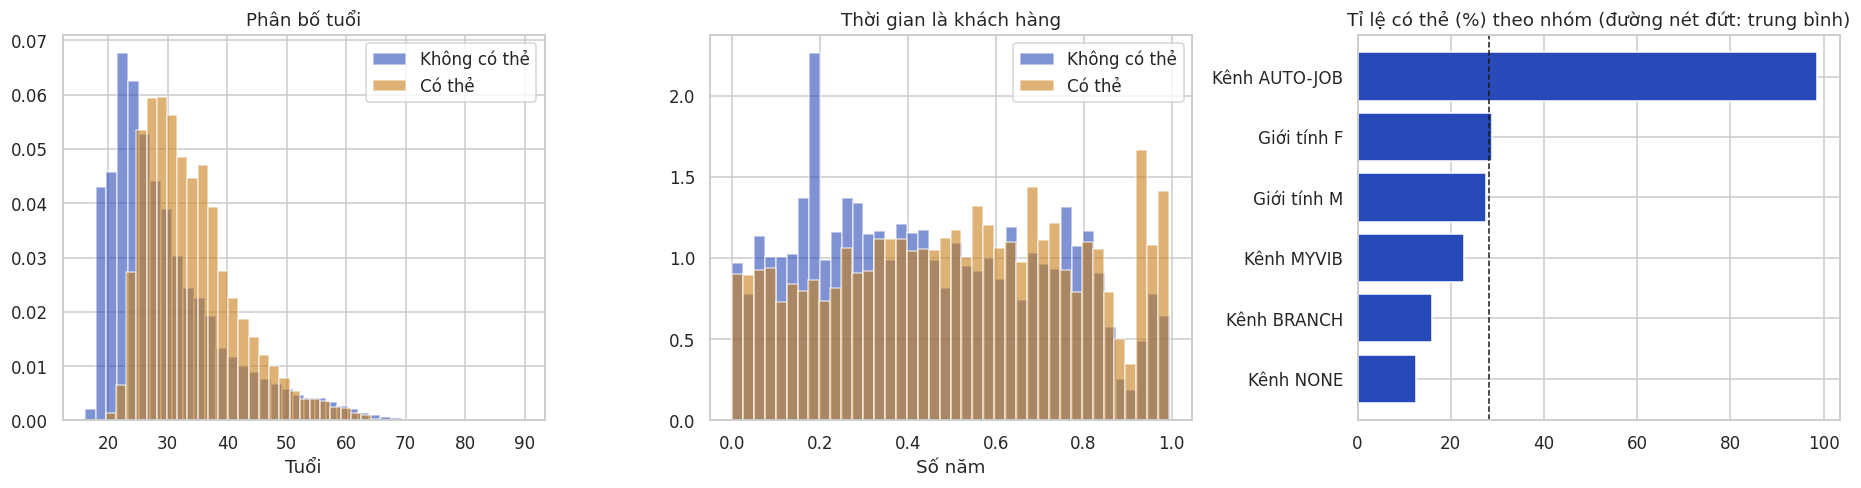

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) Tuổi theo nhãn
for lab, name, col in [(0, 'Không có thẻ', colors[0]), (1, 'Có thẻ', colors[1])]:
    axes[0].hist(feats.loc[feats.HAS_CARD == lab, 'age'].dropna(), bins=40, alpha=0.6, density=True, label=name, color=col)
axes[0].set_title('Phân bố tuổi'); axes[0].set_xlabel('Tuổi'); axes[0].legend()

# (b) Thời gian là khách hàng (năm)
for lab, name, col in [(0, 'Không có thẻ', colors[0]), (1, 'Có thẻ', colors[1])]:
    axes[1].hist(feats.loc[feats.HAS_CARD == lab, 'tenure_days'].dropna() / 365, bins=40, alpha=0.6, density=True, label=name, color=col)
axes[1].set_title('Thời gian là khách hàng'); axes[1].set_xlabel('Số năm'); axes[1].legend()

# (c) Tỉ lệ có thẻ theo kênh đăng ký và giới tính
rates = {}
for prefix in ['sex_', 'channel_']:
    for col in [x for x in feats.columns if x.startswith(prefix)]:
        sub = feats[feats[col] == 1]
        if len(sub) >= 200:
            rates[col.replace('sex_', 'Giới tính ').replace('channel_', 'Kênh ')] = sub['HAS_CARD'].mean() * 100
rates = pd.Series(rates).sort_values()
axes[2].barh(rates.index, rates.values, color='#2849b8')
axes[2].axvline(feats.HAS_CARD.mean() * 100, color='k', ls='--', lw=1)
axes[2].set_title('Tỉ lệ có thẻ (%) theo nhóm (đường nét đứt: trung bình)')
plt.tight_layout(); plt.show()

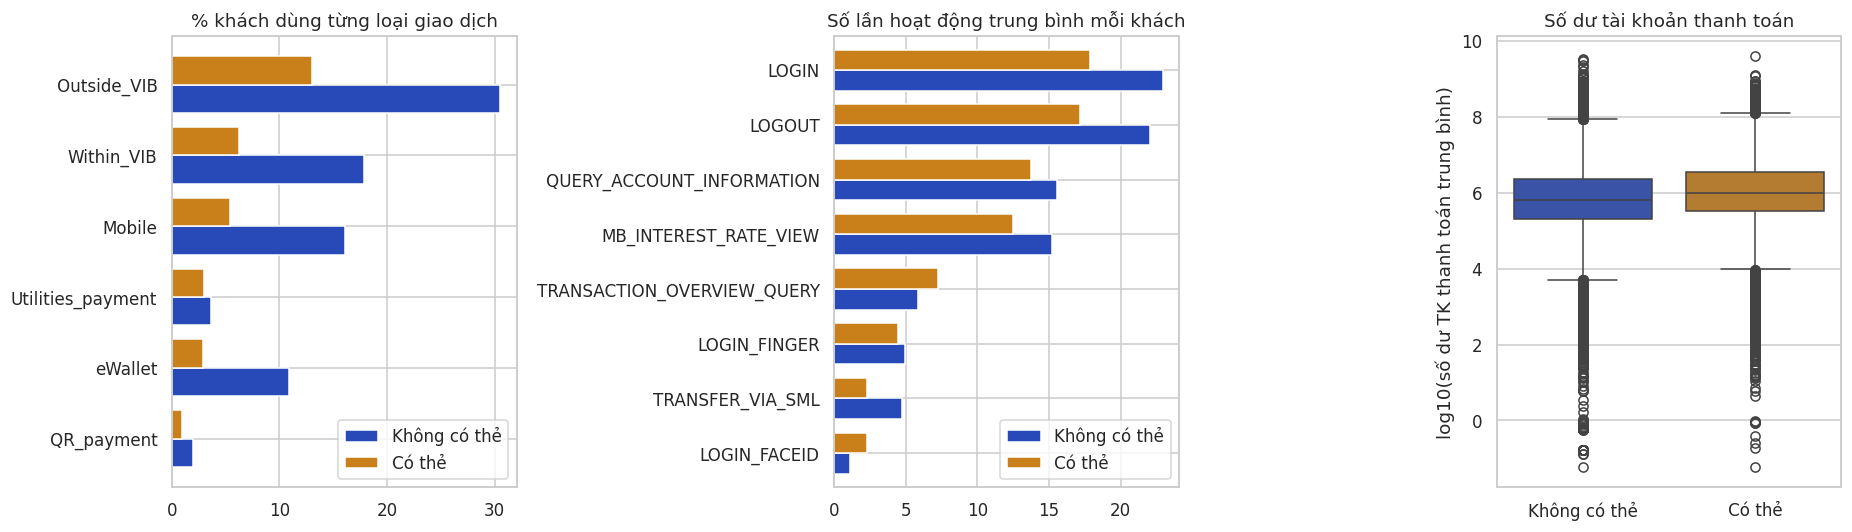

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) Tỉ lệ khách dùng từng loại giao dịch, theo nhãn
txn_cols = [x for x in feats.columns if x.startswith('txn_')]
use = pd.DataFrame({lab: (feats.loc[feats.HAS_CARD == lab, txn_cols] > 0).mean() * 100 for lab in (0, 1)})
use.index = use.index.str.replace('txn_', '')
use = use[use.max(axis=1) > 0.5].sort_values(1)
y_pos = np.arange(len(use))
axes[0].barh(y_pos - 0.2, use[0], height=0.4, color=colors[0], label='Không có thẻ')
axes[0].barh(y_pos + 0.2, use[1], height=0.4, color=colors[1], label='Có thẻ')
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(use.index)
axes[0].set_title('% khách dùng từng loại giao dịch'); axes[0].legend()

# (b) Số lần hoạt động trung bình trên app (top 8)
act_cols = [x for x in feats.columns if x.startswith('act_') and x not in ('act_total', 'act_biometric_ratio')]
top = feats[act_cols].mean().sort_values(ascending=False).head(8).index
avg = feats.groupby('HAS_CARD')[top].mean().T
avg.index = avg.index.str.replace('act_', '')
avg.sort_values(1).plot.barh(ax=axes[1], color=colors, width=0.75)
axes[1].set_title('Số lần hoạt động trung bình mỗi khách'); axes[1].legend(['Không có thẻ', 'Có thẻ'])

# (c) Số dư tài khoản thanh toán (thang log), chỉ khách có tài khoản
sub = feats[feats.ca_bal_mean > 0]
sns.boxplot(data=sub, x='HAS_CARD', y=np.log10(sub['ca_bal_mean']), hue='HAS_CARD', palette=colors, legend=False, ax=axes[2])
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(['Không có thẻ', 'Có thẻ'])
axes[2].set_xlabel(''); axes[2].set_ylabel('log10(số dư TK thanh toán trung bình)')
axes[2].set_title('Số dư tài khoản thanh toán')
plt.tight_layout(); plt.show()

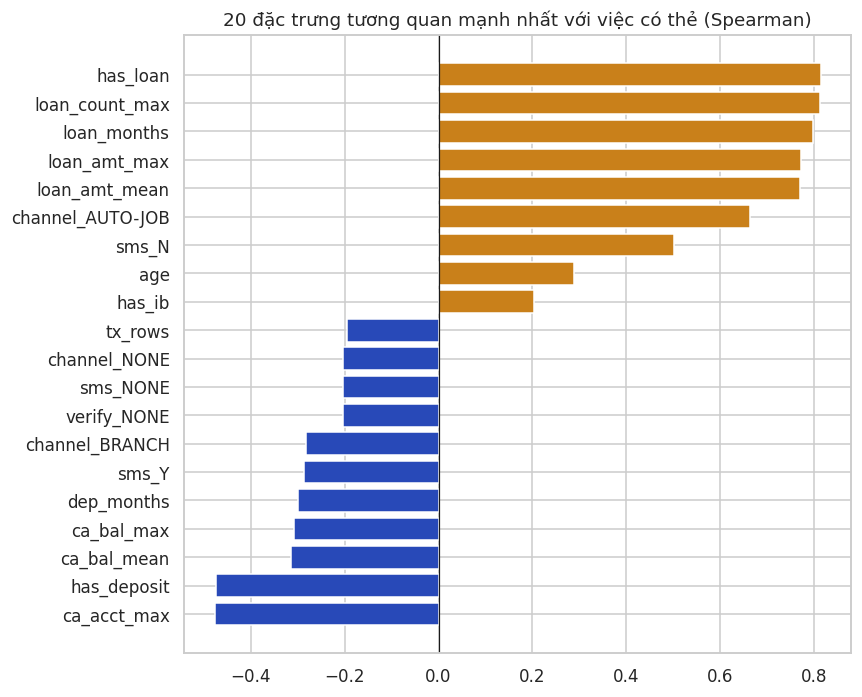

In [13]:
# Tương quan (Spearman) của từng đặc trưng với nhãn
corr = feats.drop(columns='HAS_CARD').corrwith(feats['HAS_CARD'], method='spearman').dropna()
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).head(20).index).sort_values()

plt.figure(figsize=(8, 6.5))
plt.barh(top_corr.index, top_corr.values, color=np.where(top_corr.values > 0, '#c9801a', '#2849b8'))
plt.axvline(0, color='k', lw=0.8)
plt.title('20 đặc trưng tương quan mạnh nhất với việc có thẻ (Spearman)')
plt.tight_layout(); plt.show()

## 8. Mô hình dự đoán

Chia 80% huấn luyện, 20% kiểm tra (giữ nguyên tỉ lệ nhãn). Dùng hai mô hình:
- **Hồi quy logistic**: mô hình đơn giản làm mốc so sánh (điền thiếu bằng trung vị, chuẩn hoá phân phối).
- **Gradient Boosting (HistGradientBoosting)**: mô hình cây mạnh hơn, tự xử lý giá trị thiếu.

Vì nhãn lệch (khoảng 28% có thẻ), ngoài độ chính xác còn dùng **ROC-AUC** và **PR-AUC (Average Precision)**.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,
                             classification_report, confusion_matrix, RocCurveDisplay,
                             PrecisionRecallDisplay)

X = feats.drop(columns='HAS_CARD')
y = feats['HAS_CARD']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', X_tr.shape, '| Test:', X_te.shape)
print('Mốc so sánh: luôn đoán "không có thẻ" cho độ chính xác', round(1 - y_te.mean(), 3))

models = {
    'Hồi quy logistic': make_pipeline(
        SimpleImputer(strategy='median'),
        QuantileTransformer(n_quantiles=200, output_distribution='normal', random_state=0),
        LogisticRegression(max_iter=1000, class_weight='balanced')),
    'Gradient Boosting': HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.08, class_weight='balanced', random_state=0),
}
proba = {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    proba[name] = m.predict_proba(X_te)[:, 1]

res = pd.DataFrame({
    name: {'Độ chính xác': accuracy_score(y_te, p > 0.5),
           'ROC-AUC': roc_auc_score(y_te, p),
           'PR-AUC': average_precision_score(y_te, p)}
    for name, p in proba.items()}).T.round(4)
res

Train: (120367, 113) | Test: (30092, 113)
Mốc so sánh: luôn đoán "không có thẻ" cho độ chính xác 0.718


,Độ chính xác,ROC-AUC,PR-AUC
Hồi quy logistic,0.9538,0.9906,0.9790
Gradient Boosting,0.9643,0.9943,0.9885


              precision    recall  f1-score   support

Không có thẻ       0.98      0.97      0.97     21617
      Có thẻ       0.92      0.96      0.94      8475

    accuracy                           0.96     30092
   macro avg       0.95      0.96      0.96     30092
weighted avg       0.97      0.96      0.96     30092



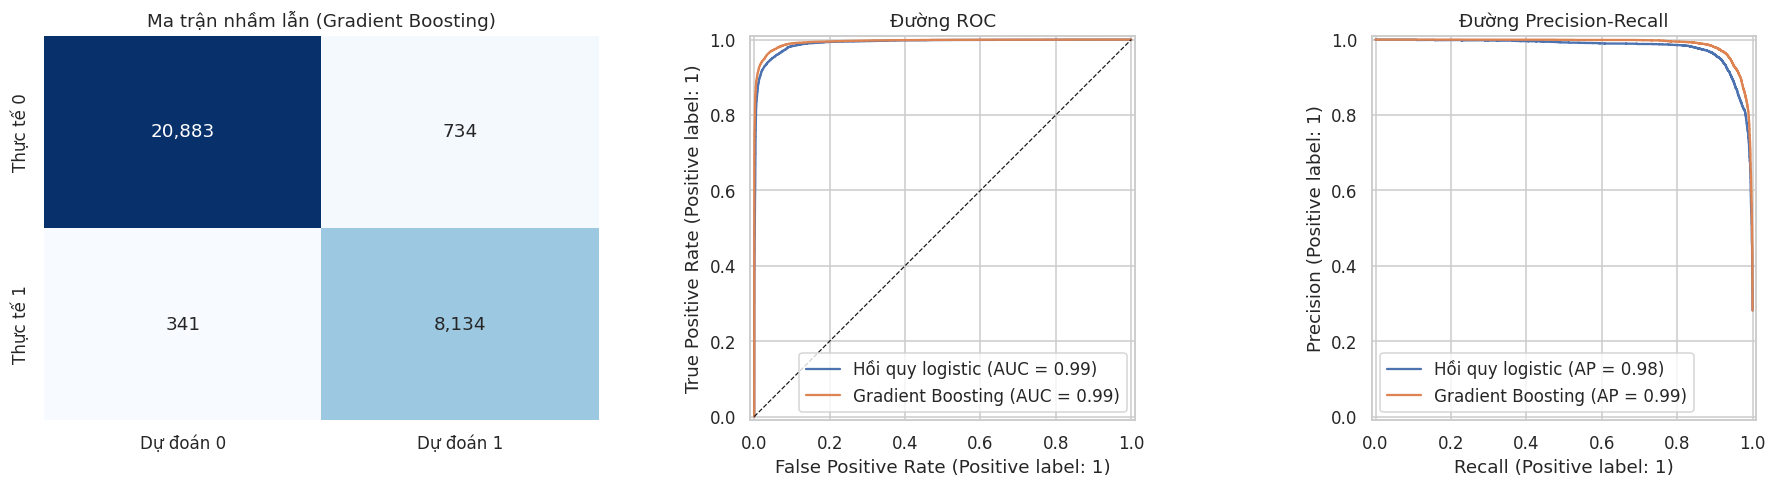

In [15]:
best = 'Gradient Boosting'
pred = (proba[best] > 0.5).astype(int)
print(classification_report(y_te, pred, target_names=['Không có thẻ', 'Có thẻ']))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
cm = confusion_matrix(y_te, pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Dự đoán 0', 'Dự đoán 1'], yticklabels=['Thực tế 0', 'Thực tế 1'])
axes[0].set_title(f'Ma trận nhầm lẫn ({best})')
for name, p in proba.items():
    RocCurveDisplay.from_predictions(y_te, p, name=name, ax=axes[1])
    PrecisionRecallDisplay.from_predictions(y_te, p, name=name, ax=axes[2])
axes[1].plot([0, 1], [0, 1], 'k--', lw=0.8); axes[1].set_title('Đường ROC')
axes[2].set_title('Đường Precision-Recall')
plt.tight_layout(); plt.show()

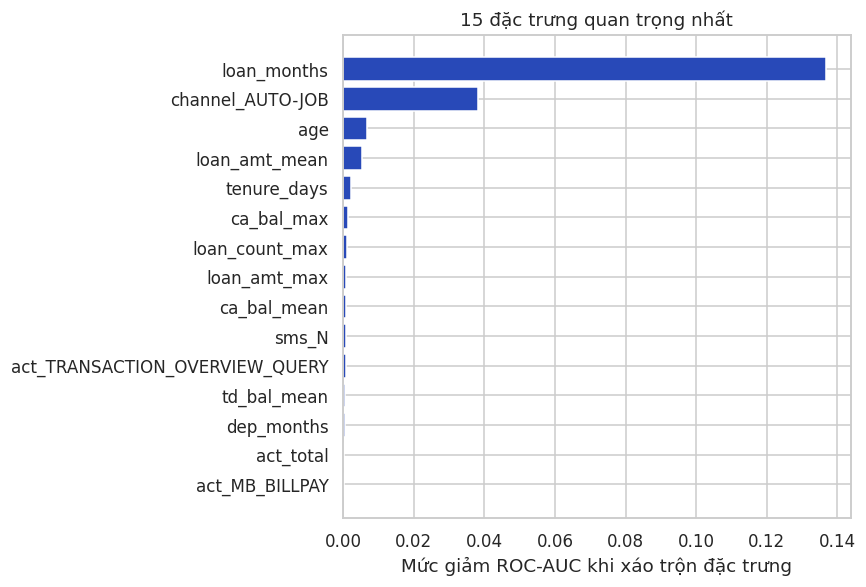

In [16]:
# Đặc trưng quan trọng nhất (permutation importance trên một mẫu tập kiểm tra)
from sklearn.inspection import permutation_importance
idx = X_te.sample(min(8000, len(X_te)), random_state=0).index
pi = permutation_importance(models[best], X_te.loc[idx], y_te.loc[idx],
                            scoring='roc_auc', n_repeats=3, random_state=0, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).head(15)[::-1]

plt.figure(figsize=(8, 5.5))
plt.barh(imp.index, imp.values, color='#2849b8')
plt.xlabel('Mức giảm ROC-AUC khi xáo trộn đặc trưng')
plt.title('15 đặc trưng quan trọng nhất')
plt.tight_layout(); plt.show()

## 9. Lưu ý khi viết báo cáo

- **Rò rỉ dữ liệu** đã được loại bỏ (`Credit_card_repayment`, `CARD_*`). Nếu giữ lại, mô hình sẽ đạt kết quả cao nhưng không có giá trị thực tế.
- **Nhãn và đặc trưng cùng nằm trong năm 2019**, nên một số khách có thể mở thẻ vào cuối năm, sau khi các đặc trưng đã được ghi nhận. Mô hình cho thấy mối liên hệ chứ chưa phải dự báo theo thời gian.
- **Phần lớn khách không có dữ liệu MyVIB** (xem biểu đồ độ phủ). Với nhóm này, đặc trưng giao dịch và hoạt động được điền 0 và có cờ `has_myvib_tx`, `has_myvib_act` để mô hình phân biệt.
- Ý nghĩa `TRANS_NO` được hiểu là số giao dịch trong mỗi dòng (gộp theo ngày, giờ, loại). Nếu đề giải thích khác, chỉ cần sửa phần trích đặc trưng ở mục 5.